In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.4 MB/s eta 0:00:00


In [ ]:
"""
Pipeline completo: Clasificación de accidentes a nivel de grafo
Materia: Aprendizaje Automático para Datos en Grafos

Supuestos sobre los datos:
  - Cada archivo .pkl contiene un grafo de NetworkX
  - Cada nodo tiene atributos: 'x', 'y' (coordenadas), 'accidentes' (conteo)
  - El grafo tiene un atributo global 'label': 1 si hubo accidente, 0 si no
  - Los archivos están en una carpeta, uno por hora
"""

# ===========================================================================
# 0. INSTALACIÓN (correr una vez en Colab o tu entorno)
# ===========================================================================
# !pip install torch-geometric

# ===========================================================================
# 1. IMPORTS
# ===========================================================================
import os
import pickle
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import TAGConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# # ===========================================================================
# # 2. CARGA Y CONVERSIÓN DE DATOS
# #    NetworkX → torch_geometric.data.Data
# # ===========================================================================

# def nx_to_pyg(G: nx.Graph) -> Data:
#     node_list = list(G.nodes())
#     node_idx  = {n: i for i, n in enumerate(node_list)}

#     # Feature de nodo: solo grado (varía poco pero da contexto estructural)
#     x = torch.tensor(
#         [[float(G.degree(n))] for n in node_list], dtype=torch.float
#     )

#     # Aristas + tiempo entre paradas como feature
#     src, dst, pesos = [], [], []
#     for u, v, attr in G.edges(data=True):
#         peso = float(attr.get('weight', 1.0))  # verificá el nombre del atributo
#         src  += [node_idx[u], node_idx[v]]
#         dst  += [node_idx[v], node_idx[u]]
#         pesos += [peso, peso]

#     edge_index = torch.tensor([src, dst], dtype=torch.long)
#     edge_attr  = torch.tensor(pesos, dtype=torch.float).unsqueeze(1)

#     y = torch.tensor([int(G.graph.get('label', 0))], dtype=torch.long)
#     return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)




# from torch_geometric.utils import add_self_loops

# def nx_to_pyg(G: nx.Graph) -> Data:
#     node_list = list(G.nodes())
#     node_idx  = {n: i for i, n in enumerate(node_list)}

#     x = torch.tensor(
#         [[float(G.degree(n))] for n in node_list], dtype=torch.float
#     )

#     src, dst, pesos = [], [], []
#     for u, v, attr in G.edges(data=True):
#         peso = float(attr.get('weight', 1.0))
#         src  += [node_idx[u], node_idx[v]]
#         dst  += [node_idx[v], node_idx[u]]
#         pesos += [peso, peso]

#     edge_index = torch.tensor([src, dst], dtype=torch.long)
#     edge_attr  = torch.tensor(pesos, dtype=torch.float).unsqueeze(1)

#     # ✅ FIX: self-loops evitan nodos con grado 0
#     edge_index, edge_weight = add_self_loops(
#         edge_index, edge_attr.squeeze(1),
#         fill_value=1.0, num_nodes=x.size(0)
#     )
#     edge_attr = edge_weight.unsqueeze(1)

#     y = torch.tensor([int(G.graph.get('label', 0))], dtype=torch.long)
#     return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)



from torch_geometric.utils import add_self_loops, degree as pyg_degree

def nx_to_pyg(G: nx.Graph) -> Data:
    node_list = list(G.nodes())
    node_idx  = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)

    # Aristas con pesos forzados a positivo
    src, dst, pesos = [], [], []
    for u, v, attr in G.edges(data=True):
        peso = abs(float(attr.get('weight', 1.0))) + 1e-6
        src  += [node_idx[u], node_idx[v]]
        dst  += [node_idx[v], node_idx[u]]
        pesos += [peso, peso]

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr  = torch.tensor(pesos, dtype=torch.float).unsqueeze(1)

    # Self-loops para evitar nodos con grado 0
    edge_index, edge_weight = add_self_loops(
        edge_index, edge_attr.squeeze(1),
        fill_value=1.0, num_nodes=num_nodes
    )
    edge_attr = edge_weight.unsqueeze(1)

    # Feature de nodo: grado calculado DESPUÉS de agregar self-loops
    deg = pyg_degree(edge_index[0], num_nodes=num_nodes, dtype=torch.float)
    x   = deg.unsqueeze(1)

    y = torch.tensor([int(G.graph.get('label', 0))], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [ ]:
def agregar_label(G: nx.Graph, columna: str = 'num_accidents') -> nx.Graph:
    """
    Agrega G.graph['label'] = 1 si algún nodo tiene columna > 0, 0 si no.
    """
    tiene_accidente = any(
        G.nodes[n].get(columna, 0) > 0
        for n in G.nodes()
    )
    G.graph['label'] = int(tiene_accidente)
    return G

In [ ]:
def cargar_dataset(carpeta: str) -> list[Data]:
    """
    Lee todos los .pkl de la carpeta y devuelve una lista de Data objects.
    Cada .pkl debe contener un grafo de NetworkX.
    """
    archivos = sorted(glob.glob(os.path.join(carpeta, "*.pkl")))
    print(f"Archivos encontrados: {len(archivos)}")

    dataset = []
    for path in archivos:
        with open(path, 'rb') as f:
            G = pickle.load(f)
        G = agregar_label(G)          # <-- línea nueva
        data = nx_to_pyg(G)
        dataset.append(data)

    n_acc = sum(int(d.y.item()) for d in dataset)
    print(f"Grafos con accidente:    {n_acc} ({100*n_acc/len(dataset):.1f}%)")
    print(f"Grafos sin accidente:    {len(dataset)-n_acc}")
    return dataset

In [ ]:
# ===========================================================================
# 3. MODELO GNN
#    TAGConv (del Lab 5) + Global Mean Pooling + MLP clasificador
# ===========================================================================
class AccidenteGNN(nn.Module):
    """
    Arquitectura:
        [node features]
             ↓
        TAGConv (K=2) × 2 capas   ← aprende representaciones de nodos
             ↓
        global_mean_pool           ← agrega nodos → un vector por grafo
             ↓
        MLP 2 capas                ← clasifica: accidente / no accidente
    """
    def __init__(self, in_channels: int, hidden: int = 64, K: int = 2):
        super().__init__()

        # Capas de convolución en grafo (del Lab 5)
        self.conv1 = TAGConv(in_channels, hidden, K=K)
        self.conv2 = TAGConv(hidden,      hidden, K=K)
        self.conv3 = TAGConv(hidden,      hidden, K=K)

        # Clasificador final (opera sobre el vector agregado del grafo)
        self.mlp = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(hidden // 2, 2),   # 2 clases: sin/con accidente
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        edge_weight = edge_attr.squeeze(1)

        x = F.relu(self.conv1(x, edge_index, edge_weight))
        x = F.relu(self.conv2(x, edge_index, edge_weight))
        x = F.relu(self.conv3(x, edge_index, edge_weight))
        x = global_mean_pool(x, batch)
        return self.mlp(x)




In [ ]:
# ===========================================================================
# 4. ENTRENAMIENTO
# ===========================================================================

def entrenar(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluar(model, loader, device):
    model.eval()
    preds, labels = [], []
    for batch in loader:
        batch  = batch.to(device)
        out    = model(batch)
        pred   = out.argmax(dim=1)
        preds.append(pred.cpu())
        labels.append(batch.y.cpu())
    preds  = torch.cat(preds)
    labels = torch.cat(labels)
    acc    = (preds == labels).float().mean().item()
    return acc, preds, labels


## SCRIPT PRINCIPAL

In [ ]:
# ===========================================================================
# 5. SCRIPT PRINCIPAL
# ===========================================================================


# --- Configuración ---
# CARPETA_GRAFOS = "/content/drive/MyDrive/Facultad (Drive)/AAGrafos/_Compartida/Proyecto/construccion_grafo/grafos"   # <-- cambiá esto a tu carpeta
# CARPETA_GRAFOS = "/content/drive/MyDrive/Facultad (Drive)/AAGrafos/_Compartida/Proyecto/construccion_grafo/grafos_diferencia"   # <-- cambiá esto a tu carpeta
# CARPETA_GRAFOS = "/content/drive/MyDrive/Facultad (Drive)/AAGrafos/_Compartida/Proyecto/construccion_grafo/grafos_diferencia_sin_filtro"   # <-- cambiá esto a tu carpeta
CARPETA_GRAFOS = "/content/drive/MyDrive/AAGrafos/Proyecto/construccion_grafo/grafos_diferencia_sin_filtro_2"   # <-- cambiá esto a tu carpeta
EPOCHS         = 100
BATCH_SIZE     = 32
LR             = 1e-4
HIDDEN         = 64
SEED           = 42

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}\n")

Usando dispositivo: cuda



In [ ]:
# --- Datos ---
dataset = cargar_dataset(CARPETA_GRAFOS)

# Split 70/15/15
train_data, test_data = train_test_split(dataset, test_size=0.3,  random_state=SEED)
val_data,   test_data = train_test_split(test_data, test_size=0.5, random_state=SEED)
print(f"\nTrain: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}\n")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE)


Archivos encontrados: 720
Grafos con accidente:    240 (33.3%)
Grafos sin accidente:    480

Train: 504 | Val: 108 | Test: 108



/tmp/ipykernel_17514/831797865.py:9: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
/tmp/ipykernel_17514/831797865.py:10: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE)
/tmp/ipykernel_17514/831797865.py:11: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE)


In [ ]:
# 1. ¿Los edge_attr realmente varían entre grafos?
d1 = dataset[0]
d2 = dataset[10]
print("Pesos grafo 0:  ", d1.edge_attr[:10].squeeze())
print("Pesos grafo 100:", d2.edge_attr[:10].squeeze())

# 2. ¿Cuántas aristas tienen peso vs peso default (1.0)?
G = pickle.load(open(sorted(glob.glob(CARPETA_GRAFOS + "/*.pkl"))[0], 'rb'))
con_peso = sum(1 for u, v, d in G.edges(data=True) if 'weight' in d)
print(f"\nAristas con peso real: {con_peso} de {G.number_of_edges()}")

Pesos grafo 0:   tensor([1.0000e-06, 1.0000e-06, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06])
Pesos grafo 100: tensor([1.0000e-06, 1.0000e-06, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0000e-06])

Aristas con peso real: 7318 de 7318


In [ ]:
for path in sorted(glob.glob(CARPETA_GRAFOS + "/*.pkl")):
    with open(path, 'rb') as f:
        G = pickle.load(f)
    con_peso = sum(1 for u, v, d in G.edges(data=True) if 'weight' in d)
    print(f"{os.path.basename(path)}: {con_peso} de {G.number_of_edges()}")

grafo_2022_09_01_00.pkl: 7318 de 7318
grafo_2022_09_01_01.pkl: 7318 de 7318
grafo_2022_09_01_02.pkl: 7318 de 7318
grafo_2022_09_01_03.pkl: 7318 de 7318
grafo_2022_09_01_04.pkl: 7318 de 7318
grafo_2022_09_01_05.pkl: 7318 de 7318
grafo_2022_09_01_06.pkl: 7318 de 7318
grafo_2022_09_01_07.pkl: 7318 de 7318
grafo_2022_09_01_08.pkl: 7318 de 7318
grafo_2022_09_01_09.pkl: 7318 de 7318
grafo_2022_09_01_10.pkl: 7318 de 7318
grafo_2022_09_01_11.pkl: 7318 de 7318
grafo_2022_09_01_12.pkl: 7318 de 7318
grafo_2022_09_01_13.pkl: 7318 de 7318
grafo_2022_09_01_14.pkl: 7318 de 7318
grafo_2022_09_01_15.pkl: 7318 de 7318
grafo_2022_09_01_16.pkl: 7318 de 7318
grafo_2022_09_01_17.pkl: 7318 de 7318
grafo_2022_09_01_18.pkl: 7318 de 7318
grafo_2022_09_01_19.pkl: 7318 de 7318
grafo_2022_09_01_20.pkl: 7318 de 7318
grafo_2022_09_01_21.pkl: 7318 de 7318
grafo_2022_09_01_22.pkl: 7318 de 7318
grafo_2022_09_01_23.pkl: 7318 de 7318
grafo_2022_09_02_00.pkl: 7318 de 7318
grafo_2022_09_02_01.pkl: 7318 de 7318
grafo_2022_0

In [ ]:
grafos = []
for path in sorted(glob.glob(CARPETA_GRAFOS + "/*.pkl")):
    with open(path, 'rb') as f:
        G = pickle.load(f)
    grafos.append((os.path.basename(path), G))

for i in range(len(grafos) - 1):
    nombre1, G1 = grafos[i]
    nombre2, G2 = grafos[i + 1]

    aristas1 = set(G1.edges())
    aristas2 = set(G2.edges())

    comunes = aristas1 & aristas2
    total   = aristas1 | aristas2

    pct = 100 * len(comunes) / len(total) if total else 0
    print(f"{nombre1} → {nombre2}: {pct:.1f}% de aristas comunes ({len(comunes)} de {len(total)})")

grafo_2022_09_01_00.pkl → grafo_2022_09_01_01.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_01.pkl → grafo_2022_09_01_02.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_02.pkl → grafo_2022_09_01_03.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_03.pkl → grafo_2022_09_01_04.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_04.pkl → grafo_2022_09_01_05.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_05.pkl → grafo_2022_09_01_06.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_06.pkl → grafo_2022_09_01_07.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_07.pkl → grafo_2022_09_01_08.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_08.pkl → grafo_2022_09_01_09.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_09.pkl → grafo_2022_09_01_10.pkl: 100.0% de aristas comunes (7318 de 7318)
grafo_2022_09_01_10.pkl → grafo_2022_09_01_11.pkl: 100.0% de aristas comunes (73

In [ ]:
import random

G = pickle.load(open(sorted(glob.glob(CARPETA_GRAFOS + "/*.pkl"))[0], 'rb'))
print("Atributos del grafo:", G.graph)
print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())
print("Atributos de un nodo:", G.nodes[list(G.nodes())[0]])
print("Atributos de una arista:", G[list(G.edges())[0][0]][list(G.edges())[0][1]])
random_arista = random.choice(list(G.edges()))
print("Atributos de una arista aleatoria:", G[random_arista[0]][random_arista[1]])

Atributos del grafo: {}
Nodos: 3721
Aristas: 7318
Atributos de un nodo: {'num_accidents': 0, 'stop_id': 4758, 'pos': (np.float64(573101.349388994), np.float64(6136722.01917165))}
Atributos de una arista: {'weight': np.float64(0.0)}
Atributos de una arista aleatoria: {'weight': np.float64(0.0)}


In [ ]:
# G.edges[(6091,3192)]

In [ ]:
# Ver todos los atributos de las primeras 3 aristas
for u, v, attr in list(G.edges(data=True))[:3]:
    print(f"{u} → {v}: {attr}")

4758 → 1290: {'weight': np.float64(0.0)}
1290 → 4771: {'weight': np.float64(1.0)}
1290 → 4909: {'weight': np.float64(1.0)}


In [ ]:
# Corré esto antes de entrenar
for i, data in enumerate(dataset[:10]):
    grados = data.x.squeeze()
    if (grados == 0).any():
        print(f"Grafo {i} tiene {(grados==0).sum().item()} nodos aislados")

Pesos de clase → sin accidente: 0.615 | con accidente: 1.385

Época   1 | Loss: 0.7186 | Val Acc: 0.5741
Época   2 | Loss: 0.7051 | Val Acc: 0.5741
Época   3 | Loss: 0.6979 | Val Acc: 0.4259
Época   4 | Loss: 0.6959 | Val Acc: 0.5741
Época   5 | Loss: 0.6978 | Val Acc: 0.5741
Época   6 | Loss: 0.6951 | Val Acc: 0.5741
Época   7 | Loss: 0.6923 | Val Acc: 0.5741
Época   8 | Loss: 0.6986 | Val Acc: 0.5741
Época   9 | Loss: 0.6927 | Val Acc: 0.5741
Época  10 | Loss: 0.6891 | Val Acc: 0.5741
Época  11 | Loss: 0.6917 | Val Acc: 0.5741
Época  12 | Loss: 0.6963 | Val Acc: 0.5741
Época  13 | Loss: 0.6927 | Val Acc: 0.5741
Época  14 | Loss: 0.6923 | Val Acc: 0.4259
Época  15 | Loss: 0.6949 | Val Acc: 0.5741
Época  16 | Loss: 0.6918 | Val Acc: 0.6019
Época  17 | Loss: 0.6913 | Val Acc: 0.6296
Época  18 | Loss: 0.6888 | Val Acc: 0.5741
Época  19 | Loss: 0.6892 | Val Acc: 0.5741
Época  20 | Loss: 0.6942 | Val Acc: 0.5741
Época  21 | Loss: 0.6943 | Val Acc: 0.6296
Época  22 | Loss: 0.6902 | Val Acc:

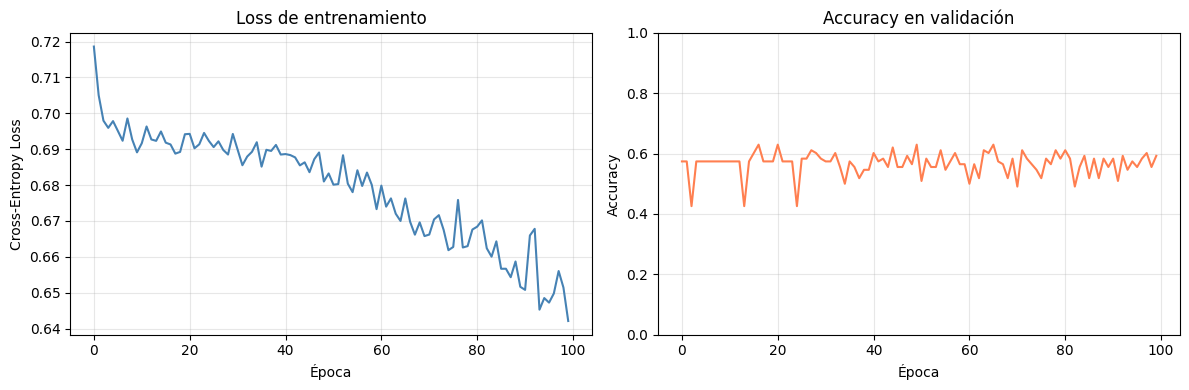


Curvas guardadas en curvas_entrenamiento.png


In [ ]:
# --- Modelo ---
# in_channels=1: (x, y, accidentes)
model     = AccidenteGNN(in_channels=1, hidden=HIDDEN).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Si el dataset está desbalanceado (pocos accidentes vs muchos sin),
# calculamos pesos para que el modelo no ignore la clase minoritaria
labels_train = torch.tensor([int(d.y.item()) for d in train_data])
n0 = (labels_train == 0).sum().float()
n1 = (labels_train == 1).sum().float()
weights = torch.tensor([1.0 / n0, 1.0 / n1])
weights = (weights / weights.sum() * 2).to(device)   # normalizado
criterion = nn.CrossEntropyLoss(weight=weights)
print(f"Pesos de clase → sin accidente: {weights[0]:.3f} | con accidente: {weights[1]:.3f}\n")

# --- Loop de entrenamiento ---
history = {"train_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    loss    = entrenar(model, train_loader, optimizer, criterion, device)
    val_acc, _, _ = evaluar(model, val_loader, device)

    history["train_loss"].append(loss)
    history["val_acc"].append(val_acc)

    # if epoch % 10 == 0:
    print(f"Época {epoch:3d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

# --- Evaluación final ---
test_acc, preds, labels = evaluar(model, test_loader, device)
print(f"\n{'='*50}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(labels, preds,
                              target_names=["Sin accidente", "Con accidente"]))
print("Matriz de confusión:")
print(confusion_matrix(labels, preds))

# --- Curvas de entrenamiento ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], color="steelblue")
ax1.set_title("Loss de entrenamiento")
ax1.set_xlabel("Época")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_acc"], color="coral")
ax2.set_title("Accuracy en validación")
ax2.set_xlabel("Época")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150)
plt.show()
print("\nCurvas guardadas en curvas_entrenamiento.png")

In [ ]:
# ===========================================================================
# BASELINE: Clasificador de clase mayoritaria (dummy classifier)
# ===========================================================================
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Extraer labels del conjunto de train y test
y_train = [int(d.y.item()) for d in train_data]
y_test = [int(d.y.item()) for d in test_data]

# Entrenar el baseline (predice siempre la clase más frecuente en train)
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit([[0]] * len(y_train), y_train) # X dummy, solo importan los labels
y_pred_baseline = dummy.predict([[0]] * len(y_test))

# Evaluación
clase_mayoritaria = dummy.classes_[dummy.class_prior_.argmax()]
print(f"Clase mayoritaria en train: {'Con accidente' if clase_mayoritaria == 1 else 'Sin accidente'} (clase {clase_mayoritaria})")
print(f"\nBaseline Accuracy: {(y_pred_baseline == y_test).mean():.4f}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_baseline,
target_names=["Sin accidente", "Con accidente"]))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_baseline))

Clase mayoritaria en train: Sin accidente (clase 0)

Baseline Accuracy: 0.6389

Reporte de clasificación:
               precision    recall  f1-score   support

Sin accidente       0.64      1.00      0.78        69
Con accidente       0.00      0.00      0.00        39

     accuracy                           0.64       108
    macro avg       0.32      0.50      0.39       108
 weighted avg       0.41      0.64      0.50       108

Matriz de confusión:
[[69  0]
 [39  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
